# EDA - PetFinder Adoption Prediction

Análisis exploratorio del dataset de entrenamiento de la competencia de Kaggle [PetFinder.my Adoption Prediction](https://www.kaggle.com/c/petfinder-adoption-prediction).

**Objetivo:** Comprender la estructura y distribución de los datos como punto de partida para el entrenamiento de un modelo predictivo de `AdoptionSpeed`, una variable objetivo ordinal con clases de 0 a 4, donde valores más bajos indican adopciones más rápidas.

**Estructura del análisis:**
1. Carga y limpieza inicial
2. Análisis univariado
3. Análisis bivariado (relación con el target)
4. Análisis multivariado

## 1. Carga y limpieza inicial

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

In [ ]:
# Rutas
BASE_PATH = "input/petfinder-adoption-prediction/"

train = pd.read_csv(BASE_PATH + 'train/train.csv')
breeds = pd.read_csv(BASE_PATH + 'breed_labels.csv')
colors = pd.read_csv(BASE_PATH + 'color_labels.csv')
states = pd.read_csv(BASE_PATH + 'state_labels.csv')

print(f'train shape: {train.shape}')
train.head()

train shape: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


### 1.1 Diccionario de variables

| Variable | Descripción |
|---|---|
| `PetID` | ID único del perfil de la mascota |
| `AdoptionSpeed` | **Target**: velocidad de adopción (0=mismo día, 1=1ª semana, 2=1er mes, 3=2do-3er mes, 4=no adoptado en 100 días) |
| `Type` | Tipo de animal (1=Perro, 2=Gato) |
| `Name` | Nombre de la mascota |
| `Age` | Edad en meses al momento del listado |
| `Breed1` | Raza primaria |
| `Breed2` | Raza secundaria (si es mestizo) |
| `Gender` | Género (1=Macho, 2=Hembra, 3=Mixto) |
| `Color1/2/3` | Colores de la mascota |
| `MaturitySize` | Tamaño al madurar (1=Pequeño, 2=Mediano, 3=Grande, 4=Extra Grande, 0=No especificado) |
| `FurLength` | Largo del pelo (1=Corto, 2=Mediano, 3=Largo, 0=No especificado) |
| `Vaccinated` | Vacunado (1=Sí, 2=No, 3=No sabe) |
| `Dewormed` | Desparasitado (1=Sí, 2=No, 3=No sabe) |
| `Sterilized` | Esterilizado (1=Sí, 2=No, 3=No sabe) |
| `Health` | Condición de salud (1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado) |
| `Quantity` | Cantidad de mascotas en el perfil |
| `Fee` | Tarifa de adopción (0=gratis) |
| `State` | Estado en Malasia |
| `RescuerID` | ID único del rescatista |
| `VideoAmt` | Cantidad de videos subidos |
| `PhotoAmt` | Cantidad de fotos subidas |
| `Description` | Texto descriptivo del perfil |

In [ ]:
# Tipos de datos
train.dtypes

Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

### 1.2 Valores nulos

In [ ]:
nulls = train.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(train) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
null_df[null_df['Nulos'] > 0]

,Nulos,Porcentaje (%)
Name,1265,8.44
Description,13,0.09


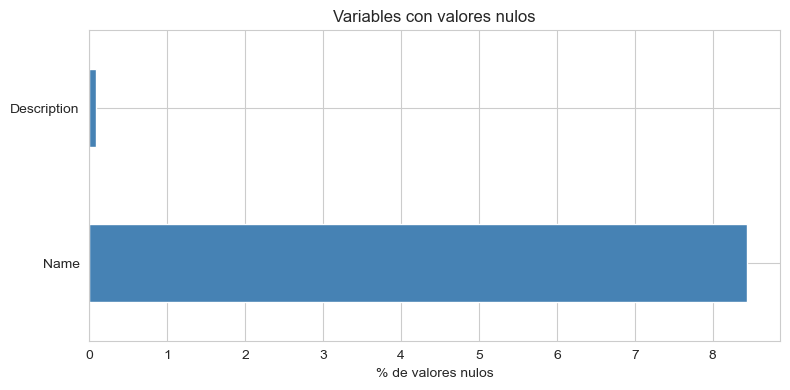

In [ ]:
# Visualización de nulos
cols_con_nulos = null_df[null_df['Nulos'] > 0]
plt.figure(figsize=(8, 4))
cols_con_nulos['Porcentaje (%)'].plot(kind='barh', color='steelblue')
plt.xlabel('% de valores nulos')
plt.title('Variables con valores nulos')
plt.tight_layout()
plt.show()

### 1.3 Mapeo de variables categóricas

Convertimos los códigos numéricos a etiquetas descriptivas para facilitar el análisis.

In [ ]:
df = train.copy()

# Mapeos según el diccionario de datos
df['Type']         = df['Type'].map({1: 'Perro', 2: 'Gato'})
df['Gender']       = df['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})
df['MaturitySize'] = df['MaturitySize'].map({0: 'No especif.', 1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'})
df['FurLength']    = df['FurLength'].map({0: 'No especif.', 1: 'Corto', 2: 'Mediano', 3: 'Largo'})
df['Vaccinated']   = df['Vaccinated'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Dewormed']     = df['Dewormed'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Sterilized']   = df['Sterilized'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Health']       = df['Health'].map({0: 'No especif.', 1: 'Sano', 2: 'Lesión leve', 3: 'Lesión grave'})

# Unión con labels de colores, razas y estados
color_map = colors.set_index('ColorID')['ColorName'].to_dict()
state_map = states.set_index('StateID')['StateName'].to_dict()
breed_map = breeds.set_index('BreedID')['BreedName'].to_dict()

# Mapeo de variables con labels
df['State']  = df['State'].map(state_map)
df['Color1'] = df['Color1'].map(color_map)
df['Color2'] = df['Color2'].map(color_map)
df['Color3'] = df['Color3'].map(color_map)
df['Breed1'] = df['Breed1'].map(breed_map)
df['Breed2'] = df['Breed2'].map(breed_map)

# Variables derivadas
df['HasName'] = df['Name'].notna() & (df['Name'].str.strip() != '') # tiene nombre
df['IsMixed'] = (train['Breed2'] != 0).astype(int) # es mestizo
df['HasPhoto'] = (df['PhotoAmt'].fillna(0) > 0).astype(int) # tiene foto
df['HasVideo'] = (df['VideoAmt'] > 0).astype(int) # tiene video
df['IsFree'] = (df['Fee'] == 0).astype(int) # adopción gratuita

print('Dataset preparado.')
df.head(3)

Dataset preparado.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,HasName,IsMixed,HasPhoto,HasVideo,IsFree
0,Gato,Nibble,3,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Sano,1,100,Selangor,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,True,0,1,0,0
1,Gato,No Name Yet,1,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,1,0,Kuala Lumpur,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,True,0,1,0,1
2,Perro,Brisco,1,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Sano,1,0,Selangor,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,True,0,1,0,1


## Feature Engineering

In [ ]:
# 1. Binning de Edad (Age está en meses)
def bin_age(age):
    if age <= 6:
        return 'Puppy/Kitten'
    elif age <= 24:
        return 'Young'
    elif age <= 84:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age'].apply(bin_age)

# 2. Flags Booleanos adicionales
# IsFree ya está en tu notebook: (df['Fee'] == 0).astype(int)

# IsPureBreed: No tiene raza secundaria y la primaria no es "Mixed Breed"
df['IsPureBreed'] = ((train['Breed2'] == 0) & (df['Breed1'] != 'Mixed Breed')).astype(int)

# HasDescription: Verifica si existe texto en la descripción
df['HasDescription'] = df['Description'].notna().astype(int)

# 3. Características de Texto: Longitud de la descripción (conteo de palabras)
df['DescriptionWordCount'] = df['Description'].fillna('').apply(lambda x: len(x.split()))

# 4. Agregaciones por Rescatista: Cantidad de mascotas publicadas por el mismo ID
df['RescuerPetCount'] = df.groupby('RescuerID')['PetID'].transform('count')

# 5. Interacción entre Foto y Video
df['HasBothPhotoVideo'] = ((df['HasPhoto'] == 1) & (df['HasVideo'] == 1)).astype(int)

# Visualizar los nuevos atributos
print(df[['Age', 'AgeGroup', 'IsPureBreed', 'DescriptionWordCount', 'RescuerPetCount']].head())

   Age      AgeGroup  IsPureBreed  DescriptionWordCount  RescuerPetCount
0    3  Puppy/Kitten            1                    69                8
1    1  Puppy/Kitten            1                    23                1
2    1  Puppy/Kitten            0                    69              459
3    4  Puppy/Kitten            0                    25               50
4    1  Puppy/Kitten            0                    81              134


In [ ]:
df.columns

Index(['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID',
       'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed',
       'HasName', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree', 'IsGroup',
       'AdoptFast', 'TypeLabel', 'VaccinatedLabel', 'DewormedLabel',
       'SterilizedLabel', 'HealthLabel', 'FeeGroup', 'PhotoGroup', 'AgeGroup',
       'IsPureBreed', 'HasDescription', 'DescriptionWordCount',
       'RescuerPetCount', 'HasBothPhotoVideo'],
      dtype='object')

In [ ]:
df.head(5)

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,IsGroup,AdoptFast,TypeLabel,VaccinatedLabel,DewormedLabel,SterilizedLabel,HealthLabel,FeeGroup,PhotoGroup,AgeGroup,IsPureBreed,HasDescription,DescriptionWordCount,RescuerPetCount,HasBothPhotoVideo
0,Gato,Nibble,3,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Sano,...,0,0,Gato,No,No,No,Sano,51-100,1-2 fotos,Puppy/Kitten,1,1,69,8,0
1,Gato,No Name Yet,1,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,...,0,1,Gato,No sabe,No sabe,No sabe,Sano,0,1-2 fotos,Puppy/Kitten,1,1,23,1,0
2,Perro,Brisco,1,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Sano,...,0,0,Perro,Sí,Sí,No,Sano,0,6+ fotos,Puppy/Kitten,0,1,69,459,0
3,Perro,Miko,4,Mixed Breed,NaN,Hembra,Black,Brown,NaN,Mediano,Corto,Sí,Sí,No,Sano,...,0,0,Perro,Sí,Sí,No,Sano,101-200,6+ fotos,Puppy/Kitten,0,1,25,50,0
4,Perro,Hunter,1,Mixed Breed,NaN,Macho,Black,NaN,NaN,Mediano,Corto,No,No,No,Sano,...,0,0,Perro,No,No,No,Sano,0,3-5 fotos,Puppy/Kitten,0,1,81,134,0


### Modelo de prueba RF

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, classification_report
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

df_rf = df.copy()

In [ ]:
# 1. Seleccionar automáticamente columnas numéricas (enteros y decimales)
num_features = df_rf.select_dtypes(include=[np.number]).columns.tolist()

# 2. Seleccionar automáticamente columnas categóricas (texto o categorías)
cat_features = df_rf.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas detectadas:", num_features)
print("Categóricas detectadas:", cat_features)

Numéricas detectadas: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree', 'IsGroup', 'AdoptFast', 'IsPureBreed', 'HasDescription', 'DescriptionWordCount', 'RescuerPetCount', 'HasBothPhotoVideo']
Categóricas detectadas: ['Type', 'Name', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'RescuerID', 'Description', 'PetID', 'HasName', 'TypeLabel', 'VaccinatedLabel', 'DewormedLabel', 'SterilizedLabel', 'HealthLabel', 'FeeGroup', 'PhotoGroup', 'AgeGroup']


In [ ]:
# 1. Definir lo que NO queremos en el modelo
columnas_target = ['AdoptionSpeed', 'AdoptFast']
columnas_texto_id = ['Name', 'Description', 'RescuerID', 'PetID']
columnas_redundantes = ['TypeLabel', 'VaccinatedLabel', 'DewormedLabel', 'SterilizedLabel', 'HealthLabel', 'FeeGroup', 'PhotoGroup']

eliminar = columnas_target + columnas_texto_id + columnas_redundantes

# 2. Filtrar las listas detectadas automáticamente
num_features_limpias = [col for col in num_features if col not in eliminar]
cat_features_limpias = [col for col in cat_features if col not in eliminar]

print("Numéricas listas para el modelo:", num_features_limpias)
print("\nCategóricas listas para el modelo:", cat_features_limpias)

# 3. Ahora sí, armas tu X y tu y
X = df_rf[num_features_limpias + cat_features_limpias]
y = df_rf['AdoptionSpeed'] # Target

Numéricas listas para el modelo: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree', 'IsGroup', 'IsPureBreed', 'HasDescription', 'DescriptionWordCount', 'RescuerPetCount', 'HasBothPhotoVideo']

Categóricas listas para el modelo: ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'HasName', 'AgeGroup']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features_limpias), # Las numéricas pasan tal cual
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features_limpias)
    ])

# Unir preprocesamiento y modelo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
])

# 6. Split de datos
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Entrenamiento
print("\nEntrenando el modelo Random Forest con Pipeline...")
rf_pipeline.fit(X_train, y_train)



In [ ]:
# 1. Configurar el preprocesador para que devuelva un DataFrame de Pandas
preprocessor.set_output(transform="pandas")

# 2. Entrenar todo el pipeline (si no lo habías hecho ya)
rf_pipeline.fit(X_train, y_train)

# 3. Extraer solo el preprocesador ya entrenado desde el pipeline
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']

# 4. Transformar X_train usando ese preprocesador
X_train_transformed_df = fitted_preprocessor.transform(X_train)

# 5. Ver una muestra aleatoria de 5 filas
muestra = X_train_transformed_df.sample(5)
display(muestra)

,num__Age,num__Quantity,num__Fee,num__VideoAmt,num__PhotoAmt,num__IsMixed,num__HasPhoto,num__HasVideo,num__IsFree,num__IsGroup,num__IsPureBreed,num__HasDescription,num__DescriptionWordCount,num__RescuerPetCount,num__HasBothPhotoVideo,...,cat__Breed1,cat__Breed2,cat__Gender,cat__Color1,cat__Color2,cat__Color3,cat__MaturitySize,cat__FurLength,cat__Vaccinated,cat__Dewormed,cat__Sterilized,cat__Health,cat__State,cat__HasName,cat__AgeGroup
6239,1,1,0,0,5.0,0,1,0,1,0,0,1,37,7,0,...,97.0,NaN,0.0,0.0,0.0,NaN,2.0,0.0,0.0,0.0,0.0,2.0,12.0,1.0,1.0
1873,12,1,0,0,2.0,0,1,0,1,0,0,1,32,17,0,...,97.0,NaN,0.0,2.0,NaN,NaN,1.0,2.0,2.0,0.0,2.0,2.0,12.0,1.0,3.0
14800,1,2,0,0,1.0,0,1,0,1,1,0,1,8,74,0,...,97.0,NaN,2.0,1.0,NaN,NaN,2.0,0.0,0.0,2.0,0.0,2.0,12.0,1.0,1.0
396,1,12,0,0,5.0,0,1,0,1,1,0,1,561,6,0,...,97.0,NaN,2.0,0.0,0.0,3.0,1.0,2.0,0.0,2.0,0.0,2.0,12.0,1.0,1.0
3995,1,1,20,0,1.0,0,1,0,0,0,0,1,25,85,0,...,97.0,NaN,0.0,0.0,4.0,NaN,2.0,0.0,0.0,0.0,0.0,2.0,9.0,1.0,1.0


In [ ]:
# 8. Evaluación
preds = rf_pipeline.predict(X_val)
qwk = cohen_kappa_score(y_val, preds, weights='quadratic')

print(f"\n--- Resultados del Modelo Random Forest ---")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")
print(classification_report(y_val, preds))



--- Resultados del Modelo Random Forest ---
Quadratic Weighted Kappa: 0.3302
              precision    recall  f1-score   support

           0       0.75      0.04      0.07        82
           1       0.38      0.29      0.33       618
           2       0.36      0.44      0.40       807
           3       0.47      0.19      0.27       652
           4       0.48      0.73      0.58       840

    accuracy                           0.42      2999
   macro avg       0.49      0.34      0.33      2999
weighted avg       0.43      0.42      0.40      2999



C:\Users\keive\AppData\Local\Temp\ipykernel_14000\3685457122.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


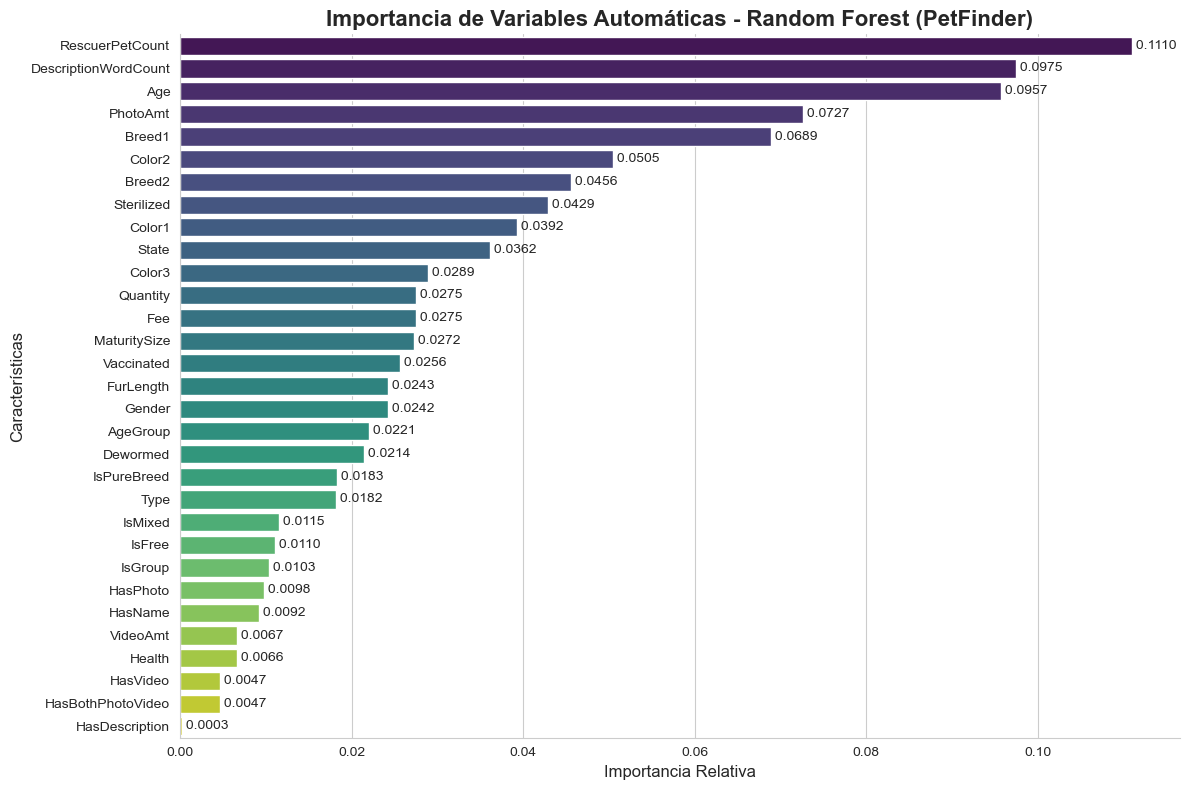

In [ ]:
# El modelo Random Forest está dentro del pipeline en el paso 'classifier'
rf_model_inside = rf_pipeline.named_steps['classifier']
importances = rf_model_inside.feature_importances_

# Obtener los nombres de las columnas en el orden exacto en que salieron del preprocesador
feature_names = num_features_limpias + cat_features_limpias

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenar para el gráfico
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Crear la visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Importancia de Variables Automáticas - Random Forest (PetFinder)', fontsize=16, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)

# Añadir valores en las barras
for index, value in enumerate(feature_importance_df['Importance']):
    plt.text(value, index, f' {value:.4f}', va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

### Modelo muy basico SVM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import cohen_kappa_score, classification_report

In [ ]:
# 4. Selección de variables
# Definimos cuáles son numéricas y cuáles categóricas para el preprocesamiento
num_features = ['Age', 'Fee', 'VideoAmt', 'PhotoAmt', 'DescriptionWordCount', 'RescuerPetCount', 'Quantity']
cat_features = ['Type', 'Breed1', 'Gender', 'Color1', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'AgeGroup']

X = df[num_features + cat_features].copy()
y = df['AdoptionSpeed']

# 5. Pipeline de Preprocesamiento (CRÍTICO para SVM)
# SVM requiere que los datos numéricos estén en la misma escala (media 0, var 1)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# 6. Definición del Pipeline con el Modelo SVM
# Usamos kernel='rbf' por defecto, que maneja relaciones no lineales
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 7. Split y Entrenamiento
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:

print("Entrenando SVM...")
svm_model.fit(X_train, y_train)

# 8. Evaluación
preds = svm_model.predict(X_val)
qwk = cohen_kappa_score(y_val, preds, weights='quadratic')

print(f"\n--- Resultados del Modelo SVM ---")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_val, preds))

Entrenando SVM...

--- Resultados del Modelo SVM ---
Quadratic Weighted Kappa: 0.3018

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.33      0.28      0.30       618
           2       0.33      0.44      0.38       807
           3       0.46      0.14      0.21       652
           4       0.47      0.69      0.56       840

    accuracy                           0.40      2999
   macro avg       0.32      0.31      0.29      2999
weighted avg       0.39      0.40      0.37      2999



c:\Users\keive\miniconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\keive\miniconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\keive\miniconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

#### Gráfico de feature importance - puede demorar

Calculando importancia por permutación (puede tomar unos segundos)...


C:\Users\keive\AppData\Local\Temp\ipykernel_14000\1856821783.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=perm_importance_df, palette='mako')


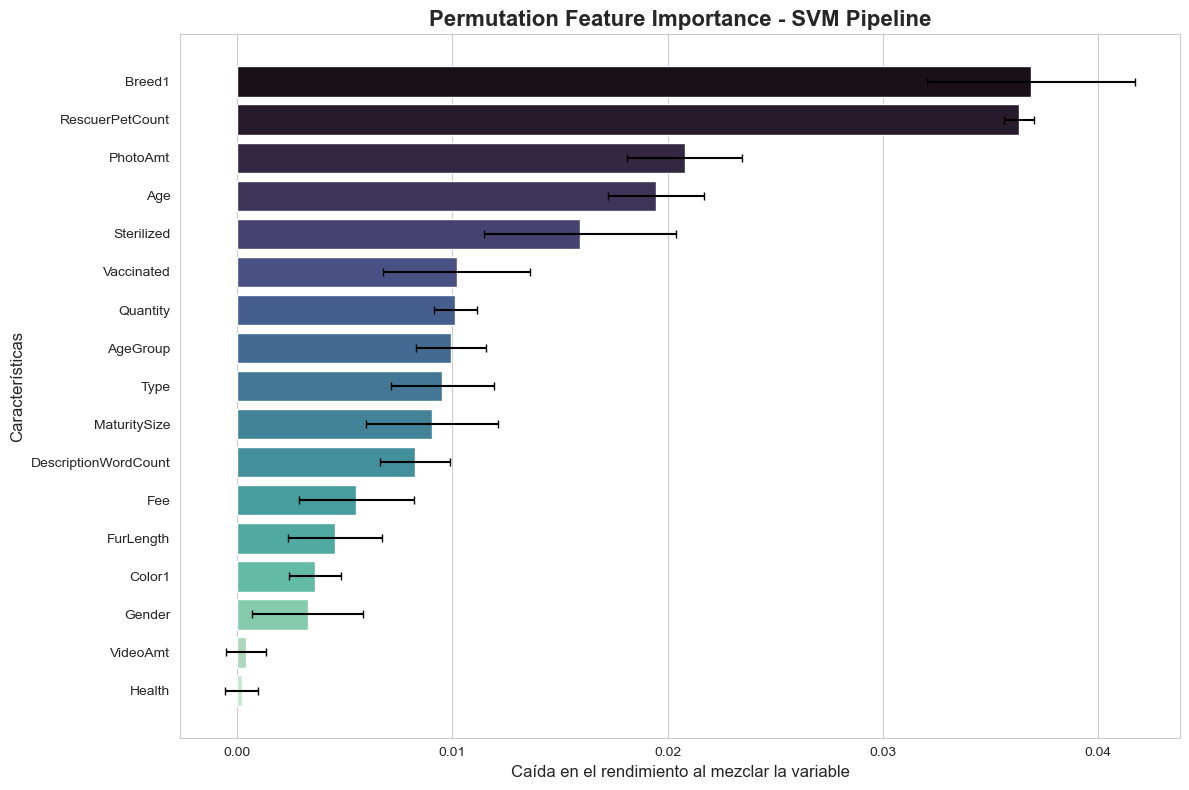

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asumiendo que tu pipeline SVM ya está entrenado bajo la variable 'svm_model'
# Usamos X_val y y_val para ver la importancia en datos no vistos (mejor práctica)

print("Calculando importancia por permutación (puede tomar unos segundos)...")
resultado_perm = permutation_importance(
    svm_model, X_val, y_val,
    n_repeats=5,        # Cuántas veces mezcla cada variable
    random_state=42,
    n_jobs=-1,          # Usa todos los procesadores
    scoring='accuracy'  # Puedes cambiarlo a tu métrica preferida
)

# Crear DataFrame con los resultados medios
perm_importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': resultado_perm.importances_mean,
    'Std_dev': resultado_perm.importances_std # Desviación estándar de las repeticiones
})

# Ordenar de mayor a menor
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df, palette='mako')

# Añadir barras de error (desviación estándar) para ver la estabilidad
plt.errorbar(x=perm_importance_df['Importance'], y=range(len(perm_importance_df)),
             xerr=perm_importance_df['Std_dev'], fmt='none', c='black', capsize=3)

plt.title('Permutation Feature Importance - SVM Pipeline', fontsize=16, fontweight='bold')
plt.xlabel('Caída en el rendimiento al mezclar la variable', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()

Esta técnica funciona así: toma una variable (ej. Age), mezcla sus valores al azar y mide qué tanto empeora el modelo. Si el modelo empeora mucho, la variable era muy importante.

### Análisis de Importancia de Variables (Permutation Importance - SVM)

A diferencia del Random Forest (donde la importancia se deriva directamente de la reducción de impureza en los nodos), el modelo SVM no ofrece una métrica de "feature importance" nativa y fácil de interpretar cuando se usa un kernel no lineal. Por esto recurrimos a la **Permutación de Variables**.

**Interpretación de los Resultados:**
1. **Variables más determinantes:** Las características que aparecen en la parte superior del gráfico provocan la mayor caída en el *accuracy* cuando sus valores se mezclan aleatoriamente. Estas son las características en las que el SVM confía más para trazar sus fronteras de decisión.
2. **Variables irrelevantes o ruidosas:** Las características cerca de cero (o incluso valores negativos) indican que el modelo no se apoya en ellas para predecir, o que incluso confunden al modelo. Dado el desempeño general del SVM, es probable que muchas variables categóricas dispersas estén aportando más ruido que señal.
3. **Estabilidad (Barras de error):** Las líneas negras muestran la desviación estándar entre las permutaciones. Una barra de error muy amplia sugiere que la importancia de esa variable es inestable.

**Siguiente paso recomendado:**
Para mejorar el modelo SVM basándonos en este gráfico, deberíamos considerar la **eliminación de variables** (Feature Selection) que tienen importancia nula o negativa, y explorar un escalado más agresivo o transformaciones en las variables que se muestran como las más relevantes.

## Conclusiones: Random Forest vs SVM

A continuación se detallan algunas observaciones luego de ejecutar y contrastar los modelos base de Random Forest y Support Vector Machine (SVM) sobre el dataset preprocesado

1. Rendimiento General (QWK):
   - El modelo Random Forest obtuvo un Quadratic Weighted Kappa (QWK) de 0.3302.
   - El modelo SVM obtuvo un QWK de 0.3018.
   - El RF demuestra ser ligeramente superior en esta métrica clave de la competencia, capturando un poco mejor el orden y penalización de las clasificaciones incorrectas.

2. Accuracy y Desempeño por Clases:
   - Random Forest (Accuracy 0.42): Muestra un desempeño más balanceado a lo largo de las distintas clases, logrando predecir casos de la clase 0 (aunque con muy bajo recall) y distribuyendo mejor sus predicciones.
   - SVM (Accuracy 0.40): Presenta dificultades severas con las clases minoritarias. En particular, la precisión para la clase 0 fue de 0.00, lo que indica que el SVM no logró identificar correctamente ninguna adopción en "Mismo día".

3. Conclusión General:
   El modelo Random Forest maneja mejor la heterogeneidad de los datos tabulares y categóricos preprocesados en comparación con el modelo SVM, que requeriría un ajuste de hiperparámetros mucho más fino para no ignorar por completo las clases minoritarias (como la clase 0). Se concluye que Random Forest es un mejor punto de partida para iterar.